In [1]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [2]:
#Gibbs energy dist from beta = 1 case, from the RSJJ model calculation value, single mode coup 1 gamma 1.4
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([4,5,3])

#Gibbs state with the degeneracy (Ergodic restriction concerned)
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div
            
            sys_gibbs.append(make_matrix_dim)
            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == False:
            return ret_matrix
        if TF == True:
            return sys_gibbs

    else:
        print("Not available input source")
        return None

In [3]:
'''
def slicing_Func(Mat):
    if Mat.shape[0] == Mat.shape[1]:
        arr = []
        for i in range(Mat.shape[0]):
            index = 0
            for j in range(Mat.shape[0]):
                if i==j and index < 2:
                    if Mat[index][index] != Mat[index+1][index+1]:
                        arr.append(index)
                        index += 1
                        break
    return(arr)
'''

Cal_Gibbs = degen_Gibbs_create(Gibbs,degeneracy,False)
Cal_Gibbs

Cal_Gibbs_T = degen_Gibbs_create(Gibbs,degeneracy,True)
Cal_Gibbs_T
#print(Cal_Gibbs)

[array([[ 0.146,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.146,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.146,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.146]]),
 array([[ 0.056,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.056,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.056,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.056,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.056]]),
 array([[ 0.046,  0.   ,  0.   ],
        [ 0.   ,  0.046,  0.   ],
        [ 0.   ,  0.   ,  0.046]])]

In [4]:
#Create Qubit system with coherence
asdf = coherent_dm(2,-1.0j)
Sys_block = asdf.full()

c = Bloch()

pointx = expect(sigmax(), asdf)
pointy = expect(sigmay(), asdf)
pointz = expect(sigmaz(), asdf)

c.add_points([pointx, pointy, pointz])
c.add_vectors([pointx, pointy, pointz])

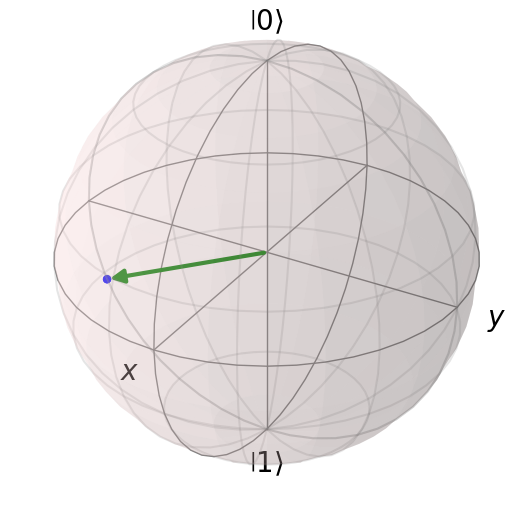

In [5]:
c.show()

In [7]:
Cal_Gibbs_T

[array([[ 0.146,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.146,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.146,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.146]]),
 array([[ 0.056,  0.   ,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.056,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.056,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.056,  0.   ],
        [ 0.   ,  0.   ,  0.   ,  0.   ,  0.056]]),
 array([[ 0.046,  0.   ,  0.   ],
        [ 0.   ,  0.046,  0.   ],
        [ 0.   ,  0.   ,  0.046]])]

In [8]:
Sys_block

array([[ 0.292+0.j   ,  0.000+0.455j],
       [ 0.000-0.455j,  0.708+0.j   ]])

In [ ]:
def Unit_block_diag_compose(sys,bath,tot):
    sys_index = (sys.shape[0])
    bath_index = len(bath)

    #print("system_index",sys_index)

    index_comb = []

    for i in range(sys_index):
        for j in range(sys_index):
            for k in range(bath_index):
                comb = ((i,j),k)
                index_comb.append(comb)

    sorted_comb = sorted(index_comb, key=lambda x: x[0][0] + x[1])
    avail_values = [sorted_comb[i][0][0] + sorted_comb[i][1] for i in range(len(sorted_comb))] #possible combinations for indices corresponding energy conditions

    value_bound = (min(avail_values),max(avail_values))
    #print("limited values : ", value_bound)
    ## 연산이 가능할 수 있는 2준위 시스템만 걸러내는 과정
    avail_values = avail_values[2:-2]
    sorted_comb = sorted_comb[2:-2]
    print("sorted result : ",sorted_comb)
    print("avail_values : ",avail_values)

    #전체 에너지 제한 값에 따른 R과 S의 에너지 조건 분리 후 따로 계산하는 과정
    sub_block_arr = []
    for k in range(len(sorted_comb)):
        sub_block = np.zeros(bath[sorted_comb[k][1]].shape[0])
        # This condition only acts under qubit case
        #print(sys[sorted_comb[k][0][0],sorted_comb[k][0][1]])
        sub_block = (sys[sorted_comb[k][0][0],sorted_comb[k][0][1]]) * bath[sorted_comb[k][1]] ## sorted_comb에 저장된 인덱스 정보에 따라 행렬 배치치
        sub_block_arr.append(sub_block)

    print(sub_block_arr)
    print(len(sub_block_arr))

    sub_block_dig = []
    sub_block_off = []

    #off-diagonal block과 diagonal block 분리
    for i in range(len(sub_block_arr)):
        if i%4 == 0 or i%4 == 3:
            sub_block_dig.append(sub_block_arr[i])
        elif i%4 == 1 or i%4 == 2:
            sub_block_off.append(sub_block_arr[i])    

    arrsize = 0 
    for l in range(len(sub_block_dig)):
        arrsize += sub_block_dig[l].shape[0]

    total_block = np.zeros((arrsize,arrsize),dtype=np.complex128)
    
    # 기존 오류 있는 루프 구조 대신 순차적 블록 배치
    row_offset = 0
    col_offset = 0

    for sub_block in sub_block_dig:
        size = sub_block.shape[0]
        total_block[row_offset:row_offset+size, col_offset:col_offset+size] = sub_block
        row_offset += size
        col_offset += size


    #print(total_block)
    #total_block = np.block([[block00,np.zeros((block00.shape[0],block00.shape[0]))],[np.zeros((block00.shape[0],block00.shape[0])),block11]])

    return total_block

In [44]:
#System construction, False case
Nup_asdf_qobj = Qobj(Sys_block)
Cal_Gibbs_qobj = Qobj(Cal_Gibbs)
rhoRS_qutip = tensor(Nup_asdf_qobj,Cal_Gibbs_qobj)

rhoRS=rhoRS_qutip.full()

print(np.trace(rhoRS))

(1.000001+0j)


sorted result :  [((0, 0), 1), ((0, 1), 1), ((1, 0), 0), ((1, 1), 0), ((0, 0), 2), ((0, 1), 2), ((1, 0), 1), ((1, 1), 1)]
avail_values :  [1, 1, 1, 1, 2, 2, 2, 2]
[array([[ 0.016+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.016+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.016+0.j,  0.000+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.000+0.j,  0.016+0.j,  0.000+0.j],
       [ 0.000+0.j,  0.000+0.j,  0.000+0.j,  0.000+0.j,  0.016+0.j]]), array([[ 0.+0.025j,  0.+0.j   ,  0.+0.j   ,  0.+0.j   ,  0.+0.j   ],
       [ 0.+0.j   ,  0.+0.025j,  0.+0.j   ,  0.+0.j   ,  0.+0.j   ],
       [ 0.+0.j   ,  0.+0.j   ,  0.+0.025j,  0.+0.j   ,  0.+0.j   ],
       [ 0.+0.j   ,  0.+0.j   ,  0.+0.j   ,  0.+0.025j,  0.+0.j   ],
       [ 0.+0.j   ,  0.+0.j   ,  0.+0.j   ,  0.+0.j   ,  0.+0.025j]]), array([[ 0.-0.066j,  0.+0.j   ,  0.+0.j   ,  0.+0.j   ],
       [ 0.+0.j   ,  0.-0.066j,  0.+0.j   ,  0.+0.j   ],
       [ 0.+0.j   ,  0.+0.j 

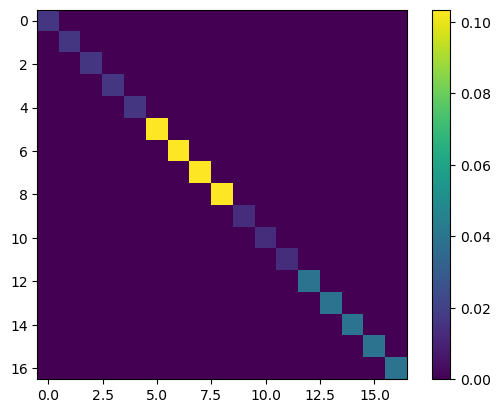

In [49]:
testbed = Unit_block_diag_compose(Sys_block,Cal_Gibbs_T,rhoRS)

plt.imshow(testbed.real)
plt.colorbar()

In [13]:
Cal_Gibbs

array([[ 0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.056,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.056,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.056,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.056,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.056,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,

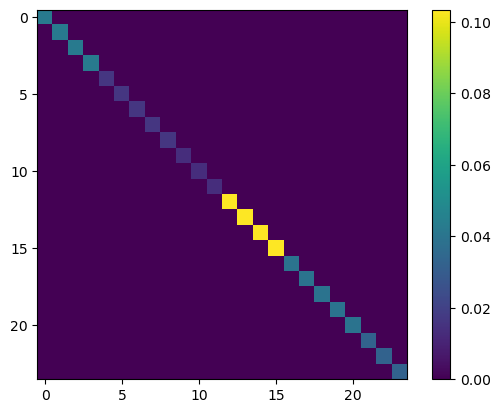

In [50]:
#coherence가 있는 경우 off-diagonal term은 존재한다. 다만 복소수 형태로 존재하는것에 유의할 것.
plt.imshow(rhoRS.real,cmap='viridis')
plt.colorbar()

#plt.savefig("/home/lie01/Works/ouput.png",format='png',bbox_inches='tight')

In [38]:
testlist = [1,2,3,4,5,6,7,8,9,10,11,12]
blanklist = [] 
offlist = []

for i in range(len(testlist)):
    if i%4 == 0 or i%4 == 3:
        print("0,3 case : ",i%4)
        blanklist.append(testlist[i])
    elif i%4 == 1 or i%4 == 2:
        print("1,2 case :",i%4)
        offlist.append(testlist[i])

print("1st,4th elements : ",blanklist)
print("2nd, 3rd elements : ",offlist)

0,3 case :  0
1,2 case : 1
1,2 case : 2
0,3 case :  3
0,3 case :  0
1,2 case : 1
1,2 case : 2
0,3 case :  3
0,3 case :  0
1,2 case : 1
1,2 case : 2
0,3 case :  3
1st,4th elements :  [1, 4, 5, 8, 9, 12]
2nd, 3rd elements :  [2, 3, 6, 7, 10, 11]


In [34]:
2%4

2